In [73]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
from timeit import default_timer as timer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [3]:
image,label=train_data[0]
image.shape,label

(torch.Size([1, 28, 28]), 9)

In [4]:
len(train_data),len(test_data)

(60000, 10000)

In [5]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [7]:
train_data_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_data_loader=DataLoader(test_data,batch_size=32,shuffle=False)

In [8]:
train_data_loader,test_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x2667838bcb0>,
 <torch.utils.data.dataloader.DataLoader at 0x266784d91d0>)

In [23]:
class cnn(nn.Module):
    def __init__(self,input_shape,output_shape,hidden_units):
        super().__init__()

        self.block1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                     out_channels=hidden_units,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                        stride=2)
        )

        self.block2=nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     kernel_size=3,
                     padding=1,
                     stride=1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                        stride=2)
        )
        
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                     out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.block2(self.block1(x)))

In [24]:
def training_pipeline(model,data_loader,loss_func,optimizer):
    training_loss,training_accuracy=0,0
    for x,y in data_loader:
        model.train()
        y_logit=model(x)
        loss=loss_func(y_logit,y)
        training_loss+=loss
        training_accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    training_loss/=len(data_loader)
    training_accuracy/=len(data_loader)
    print(f"Training loss is {training_loss}")
    print(f"Training accuracy is {training_accuracy}")

In [25]:
def testing_pipeline(model,data_loader,loss_func):
    loss,accuracy=0,0
    model.eval()
    with torch.inference_mode():
        for x,y in data_loader:
            y_logit=model(x)
            loss+=loss_func(y_logit,y)
            accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        loss/=len(data_loader)
        accuracy/=len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": accuracy}

In [26]:
torch.manual_seed(18)
model=cnn(1,len(class_names),10)
model

cnn(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [27]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [28]:
torch.manual_seed(18)
epochs=3
start_time=timer()
for epoch in tqdm(range(epochs)):
    print(f"-----Epoch {epoch+1}-----")
    training_pipeline(model,train_data_loader,loss_func,optimizer)
end_time=timer()
print(f"Total time taken for training is {end_time-start_time}")

  0%|          | 0/3 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 1.5837417840957642
Training accuracy is 0.4380833333333333
-----Epoch 2-----
Training loss is 0.5257518291473389
Training accuracy is 0.8075833333333333
-----Epoch 3-----
Training loss is 0.4268820583820343
Training accuracy is 0.8457333333333333
Total time taken for training is 180.30850349995308


In [29]:
model_results=testing_pipeline(model,test_data_loader,loss_func)
model_results

{'model_name': 'cnn',
 'model_loss': 0.4121807813644409,
 'model_acc': 0.8521365814696485}

In [39]:
def predict(model,data):
    preds=[]
    model.eval()
    with torch.inference_mode():
        for sample in data:
            pred_logit=model(sample.unsqueeze(dim=0))
            pred=pred_logit.argmax(dim=1)
            preds.append(pred)
    return torch.stack(preds).squeeze()

In [40]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [41]:
import random
torch.manual_seed(42)
test_samples=[]
test_labels=[]
for sample,label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)

In [42]:
preds=predict(model,test_samples)
preds

tensor([6, 1, 9, 3, 3, 7, 5, 5, 4])

In [43]:
test_labels

[6, 1, 9, 3, 0, 7, 5, 5, 4]

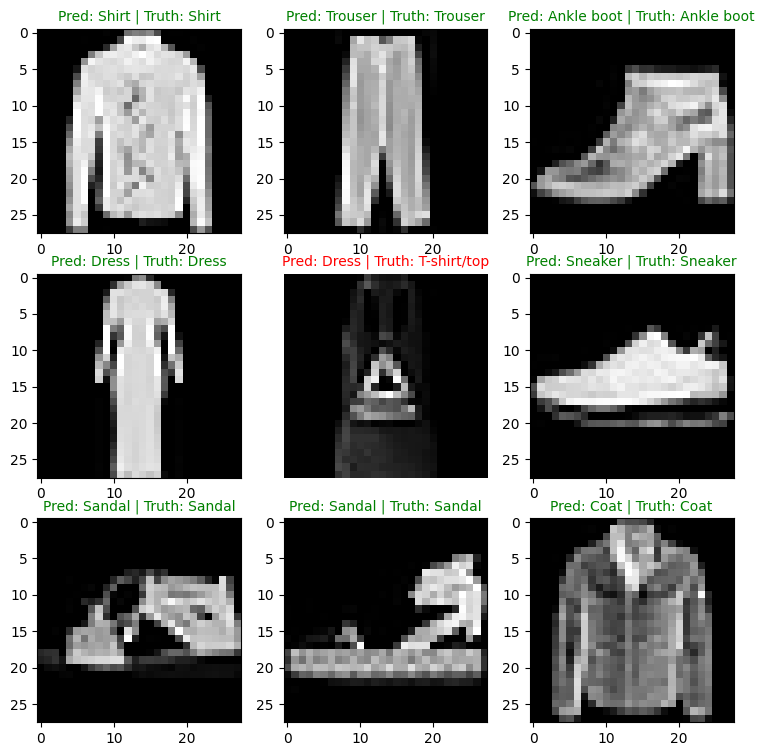

In [49]:
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.squeeze(),cmap="gray")
    prediction=class_names[preds[i]]
    truth_labels=class_names[test_labels[i]]
    title_text = f"Pred: {prediction} | Truth: {truth_labels}"
    if prediction == truth_labels:
      plt.title(title_text, fontsize=10, c="g")
    else:
      plt.title(title_text, fontsize=10, c="r")
      plt.axis(False)

In [52]:
len(test_data)

10000

In [58]:
test_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [61]:
y_true=test_data.targets
len(y_true)

10000

In [67]:
x = test_data.data.unsqueeze(1).float()/255
len(x)

10000

In [69]:
model.eval()
with torch.inference_mode():
    y_logit=model(x)
    len(y_logit)

In [71]:
y_pred=y_logit.argmax(dim=1)
y_pred

tensor([9, 2, 1,  ..., 8, 1, 5])

In [75]:
cm=confusion_matrix(y_true.numpy(),y_pred.numpy())
cm

array([[706,   3,  26,  81,   4,   1, 164,   0,  15,   0],
       [  0, 954,   1,  34,   5,   0,   5,   0,   1,   0],
       [  9,   3, 820,  10,  83,   0,  68,   0,   7,   0],
       [ 10,   7,  20, 893,  21,   0,  46,   0,   3,   0],
       [  0,   0, 155,  47, 696,   0,  99,   0,   3,   0],
       [  0,   0,   0,   2,   0, 933,   0,  41,   0,  24],
       [ 90,   3, 105,  43,  74,   0, 662,   0,  23,   0],
       [  0,   0,   0,   0,   0,  22,   0, 930,   0,  48],
       [  0,   2,   5,   6,   2,   2,  14,   6, 961,   2],
       [  0,   0,   0,   0,   0,   3,   0,  30,   1, 966]])

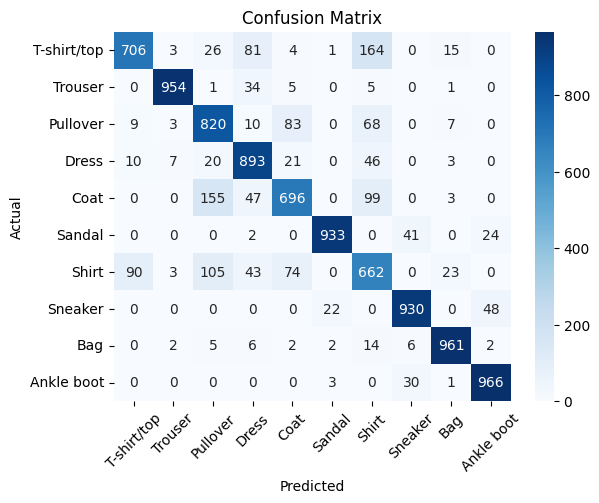

In [88]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
# plt.axis("off")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [90]:
torch.save(model.state_dict(),"cnn.pth")

In [91]:
torch.manual_seed(18)
model0=cnn(1,len(class_names),10)
model0.load_state_dict(torch.load("cnn.pth"))

<All keys matched successfully>

In [93]:
model0.parameters

<bound method Module.parameters of cnn(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)>